<a href="https://colab.research.google.com/github/Fabiane-Gaspar/Projeto_PUC_ML/blob/main/Regress%C3%A3o_Linear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#REGRESSÃO LINEAR

##Objetivo: Provisionar com bases nas variáveis uma estimativa de salário de uma pessoa.

#Tratando e Preparando os Dados

- Filtrando os dados que iremos trabalhar
- Criando novas colunas
- Pegando primeiro digito de coluna com a função Extract
- Substituindo valores
- Preenchendo linhas nulas com função fillna



In [ ]:
#importando bibliotecas
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error #importando as 3 bibliotecas de métricas (MSE, R², MAE)
from sklearn.model_selection import train_test_split #baixando a biblioteca de treino e teste
from sklearn.preprocessing import StandardScaler #essa função tem como objetivo padronizar as características, removendo a média e escalando para variança unitária(normalizar o dados)
from sklearn.linear_model import LinearRegression #importando a biblioteca de regressão linear
import matplotlib.pyplot as plt



In [ ]:
#lendo o arquivo em excel e salvando na variável dados
dados = pd.read_excel('/content/drive/MyDrive/Programaria/analise_dados_mod7_(1).xlsx')

In [ ]:
#analisando os dados 5 primeiras linhas
dados.head()

,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,ESTADO ONDE MORA,...,Você pretende mudar de emprego nos próximos 6 meses?,Quais os principais critérios que você leva em consideração no momento de decidir onde trabalhar?,Atualmente qual a sua forma de trabalho?,Qual a forma de trabalho ideal para você?,Caso sua empresa decida pelo modelo 100% presencial qual será sua atitude?,Sua empresa passu por Layoff em 2022?,Atuacao,Quais das linguagens listadas abaixo você utiliza no trabalho?,EM_BUSCA,ABERTO_OPORTUNIDADES
0,zzqzz3l9ily8nuo2m7wyzzqzz3w48o96,39.0,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,Distrito Federal (DF),...,Não estou buscando e não pretendo mudar de emp...,Benefícios,Modelo 100% presencial,Modelo híbrido com dias fixos de trabalho pres...,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Engenharia de Dados,SQL,0.0,0.0
1,zzls2oftfn9law393oezzls2ofhvfpzd,32.0,30-34,Masculino,Parda,Não,"Sim, acredito que a minha a experiência profis...",Aprovação em processos seletivos/entrevistas,True,Pará (PA),...,Estou em busca de oportunidades dentro ou fora...,"Remuneração/Salário, Plano de carreira e oport...",Modelo 100% presencial,Modelo híbrido flexível (o funcionário tem lib...,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Gestor,NaN,1.0,0.0
2,zzdwqzfqqp1ypc7ps6m0hzzdwqz292yi,53.0,50-54,Masculino,Branca,Não,NaN,NaN,True,Distrito Federal (DF),...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Flexibilidade de trabalho...",Modelo híbrido com dias fixos de trabalho pres...,Modelo híbrido flexível (o funcionário tem lib...,Vou procurar outra oportunidade no modelo híbr...,Não ocorreram layoffs/demissões em massa na em...,desenvolve modelos preditivos e algoritmos de ...,1,0.0,1.0
3,zzbqh3uy7yk7k9qmkzzbqtb4s9faqspl,27.0,25-29,Masculino,Branca,Não,NaN,NaN,True,Minas Gerais (MG),...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Flexibilidade de trabalho...",Modelo híbrido flexível (o funcionário tem lib...,Modelo híbrido flexível (o funcionário tem lib...,Vou procurar outra oportunidade no modelo híbr...,Não ocorreram layoffs/demissões em massa na em...,desenvolve modelos preditivos e algoritmos de ...,0,0.0,1.0
4,zzaf1m95yan929rb94wzzaf1mekhvhpg,46.0,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,Pará (PA),...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Oportunidade de aprendiza...",Modelo 100% presencial,Modelo 100% presencial,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Outra atuação,SQL,0.0,1.0


In [ ]:
#analisando os títulos do cabeçalho para verificar qual a coluna informa o tipo de trabalho
dados.columns

Index(['ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA', 'PCD',
       'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'UF ONDE MORA',
       'REGIAO ONDE MORA', 'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM',
       'NIVEL DE ENSINO', 'ÁREA DE FORMAÇÃO',
       'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO', 'NOVO_NIVEL', 'NIVEL_Júnior', 'NIVEL_Pleno', 'NIVEL_Sênior',
       'GEARACAO', 'Quanto tempo de experiência na área de dados você tem?',
       'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?',
       'Você está satisfeito na sua 

In [ ]:
#analizando a coluna situação de trabalho para verificar a quantidade (contagem) de cada resposta e identificando os tipos "CLT"
dados['QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?'].value_counts()

,count
QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?,
Empregado (CLT),2762
Empreendedor ou Empregado (CNPJ),410
"Desempregado, buscando recolocação",350
Estagiário,188
Servidor Público,156
Trabalho na área Acadêmica/Pesquisador,86
Somente Estudante (graduação),82
Vivo no Brasil e trabalho remoto para empresa de fora do Brasil,69
Vivo fora do Brasil e trabalho para empresa de fora do Brasil,46


In [ ]:
#salvando uma nova variável com o filtro na coluna de situação de trabalho que sejam apenas CLT
dados = dados[dados['QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?'] == 'Empregado (CLT)']

In [ ]:
#verificando se o filtro ficou correto e deve aparecer na nova contagem apenas os CLT
dados['QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?'].value_counts()

,count
QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?,
Empregado (CLT),2762


In [ ]:
#usando value_counts para contar as respostas da coluna 'COR, RAÇA E ETNIA'
dados['COR/RACA/ETNIA'].value_counts()

,count
COR/RACA/ETNIA,
Branca,1805
Parda,661
Preta,181
Amarela,85
Prefiro não informar,16
Outra,10
Indígena,4


In [ ]:
#retirando as resposta com baixo numero, salvando em uma variável e colocando em lista
lista_retirar = ['Prefiro não informar', 'Outra','Indígena']

In [ ]:
#usando o "~" para que faça o contrário da função ISIN (se esta) para filtrar e retirar e salvando na varável dados
dados = dados[~dados['COR/RACA/ETNIA'].isin(lista_retirar)]

In [ ]:
#fazendo uma nova coluna e atribuindo valores para: não branco 1 e branco 0, utilizando apply, e condicional
dados['NÃO_BRANCA'] = dados['COR/RACA/ETNIA'].apply(lambda x: 1 if x != 'Branca' else 0)


In [ ]:
#utilizando outro atributo para filtrar será o tempo de trabalho, vamos verificar a contagem das resposta
dados['QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?'].value_counts()

,count
QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,
de 1 a 2 anos,743
de 3 a 4 anos,584
de 4 a 6 anos,416
Menos de 1 ano,353
Mais de 10 anos,277
de 7 a 10 anos,232
Não tenho experiência na área de dados,127


In [ ]:
#criando nova coluna
#utilizando ".str" para acessar apenas a string e dentro da função() extract o que queremos extrair, que será uma expressão
#o "r" signfica uma string crua ou rais, o "\d" significa de 0 a 9, e o "+" significa um quantificados de um ou mais do que procede.
dados['TEMPO DE EXPERIENCIA'] = dados['QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?'].str.extract(r'(\d+)')

In [ ]:
dados['TEMPO DE EXPERIENCIA'].value_counts()

,count
TEMPO DE EXPERIENCIA,
1,1096
3,584
4,416
10,277
7,232


In [ ]:
#substituindo valores com função replace, retirando ". ponto" e deixando nada
dados['NUMERO DE FUNCIONARIOS'] = dados['NUMERO DE FUNCIONARIOS'].str.replace('.','')

In [ ]:
#verificando se o código acima deu certo com a retirada dos ponto e contando respostas
dados['NUMERO DE FUNCIONARIOS'].value_counts()

,count
NUMERO DE FUNCIONARIOS,
Acima de 3000,1313
de 101 a 500,503
de 1001 a 3000,368
de 501 a 1000,248
de 51 a 100,146
de 11 a 50,112
de 6 a 10,24
de 1 a 5,18


In [ ]:
#extraindo apenas os digitos após a string e salvando em um nova coluna em cima da existente com mesmo nome
dados['NUMERO DE FUNCIONARIOS'] = dados['NUMERO DE FUNCIONARIOS'].str.extract(r'(\d+)')

In [ ]:
#fazendo contagem e verificando com a função dropna se não tem nulos
dados['NUMERO DE FUNCIONARIOS'].value_counts(dropna=False)

,count
NUMERO DE FUNCIONARIOS,
3000,1313
101,503
1001,368
501,248
51,146
11,112
6,24
1,18


In [ ]:
#fazendo contagem e verificando com a função dropna se não tem nulos
dados['TEMPO DE EXPERIENCIA'].value_counts(dropna=False)


,count
TEMPO DE EXPERIENCIA,
1,1096
3,584
4,416
10,277
7,232
NaN,127


In [ ]:
#usando a função "fillna" para preencher linhas nulas, neste caso preenchemos com "0"
dados['TEMPO DE EXPERIENCIA'] = dados['TEMPO DE EXPERIENCIA'].fillna(0)

In [ ]:
#verificando que não temos mais o nulo NaN
dados['TEMPO DE EXPERIENCIA'].value_counts(dropna=False)

,count
TEMPO DE EXPERIENCIA,
1,1096
3,584
4,416
10,277
7,232
0,127


In [ ]:
dados['Qual o principal motivo da sua insatisfação com a empresa atual?'].value_counts()

,count
Qual o principal motivo da sua insatisfação com a empresa atual?,
Gostaria de trabalhar em em outra área de atuação,69
Salário atual não corresponde ao mercado,53
Falta de oportunidade de crescimento no emprego atual,46
Falta de maturidade analítica na empresa,45
"Falta de oportunidade de crescimento no emprego atual, Salário atual não corresponde ao mercado, Falta de maturidade analítica na empresa",26
...,...
Trabalho explora pouco minhas habilidades e me dá poucas oportunidades de atuação distintas,1
Quero trabalhar de casa,1
"Não tenho uma boa relação com meu líder/gestor, Gostaria de trabalhar em em outra área de atuação",1


In [ ]:
dados['INSATISFACAO'] = 0

In [ ]:
#usando função loc para acessar uma coluna específica e o nitnull para filtrar essa coluna.Utilizando apply para Transformar dados de um formato para outro com o lambda
#se tiver a palavra salário é 1, se não é 0
dados.loc[dados['Qual o principal motivo da sua insatisfação com a empresa atual?'].notnull(),'Qual o principal motivo da sua insatisfação com a empresa atual?'].apply(lambda x: 1 if 'Salário' in x else 0)

,Qual o principal motivo da sua insatisfação com a empresa atual?
1,0
2,0
7,1
10,0
26,1
...,...
4227,0
4234,1
4238,0
4240,1


In [ ]:
#atribuindo o tratamento feito na linha de cima na nova coluna de insatisfação
dados.loc[dados['Qual o principal motivo da sua insatisfação com a empresa atual?'].notnull(),'INSATISFACAO'] = dados.loc[dados['Qual o principal motivo da sua insatisfação com a empresa atual?'].notnull(),'Qual o principal motivo da sua insatisfação com a empresa atual?'].apply(lambda x: 1 if 'Salário' in x else 0)

In [ ]:
#contando e verificando se deu certo a transformação
dados['INSATISFACAO'].value_counts()

,count
INSATISFACAO,
0,2453
1,279


In [ ]:
dados['NIVEL DE ENSINO'].value_counts()

,count
NIVEL DE ENSINO,
Graduação/Bacharelado,1024
Pós-graduação,975
Mestrado,306
Estudante de Graduação,271
Doutorado ou Phd,100
Não tenho graduação formal,52
Prefiro não informar,4


In [ ]:
#Substituindo cada categoria da coluna de ‘NIVEL DE ENSINO’ por um valor. Na ordem crescente de escolaridade, por exemplo: 0 para “Não tenho graduação formal”, 1 para “Estudante de Graduação”, 2 para “Graduação/Bacharelado”, e assim por diante.
dados["NIVEL DE ENSINO"] = dados["NIVEL DE ENSINO"].apply(lambda x:
  0 if x == "Não tenho graduação formal" else
  1 if x == "Estudante de Graduação" else
  2 if x == "Graduação/Bacharelado" else
  3 if x == "Pós-graduação" else
  4 if x == "Mestrado" else
  5 if x == "Doutorado ou Phd" else -1)

## Selecionando os atributos que iremos usar no nosso modelo


> Adicionar aspas



In [ ]:
dados.columns

Index(['ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA', 'PCD',
       'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'UF ONDE MORA',
       'REGIAO ONDE MORA', 'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM',
       'NIVEL DE ENSINO', 'ÁREA DE FORMAÇÃO',
       'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO', 'NOVO_NIVEL', 'NIVEL_Júnior', 'NIVEL_Pleno', 'NIVEL_Sênior',
       'GEARACAO', 'Quanto tempo de experiência na área de dados você tem?',
       'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?',
       'Você está satisfeito na sua 

In [ ]:
#selecionando os atributos (colunas)
dados = dados[['IDADE', 'GENERO', 'NÃO_BRANCA','TEMPO DE EXPERIENCIA', 'INSATISFACAO', 'SETOR','REGIAO ONDE MORA','NIVEL DE ENSINO',  'NUMERO DE FUNCIONARIOS','SALARIO', 'NOVO_NIVEL']]

In [ ]:
#usando a função Get_dummies nos dados que não tem ordenação e drop_first=True para cortar a primeira coluna
dados = pd.get_dummies(dados, columns=['GENERO', 'SETOR', 'NOVO_NIVEL', 'REGIAO ONDE MORA'], drop_first=True)

In [ ]:
dados

,IDADE,NÃO_BRANCA,TEMPO DE EXPERIENCIA,INSATISFACAO,NIVEL DE ENSINO,NUMERO DE FUNCIONARIOS,SALARIO,GENERO_Masculino,GENERO_Prefiro não informar,SETOR_Educação,...,SETOR_Varejo,SETOR_Área da Saúde,SETOR_Área de Consultoria,NOVO_NIVEL_Pessoa Gestora,NOVO_NIVEL_Pleno,NOVO_NIVEL_Sênior,REGIAO ONDE MORA_Nordeste,REGIAO ONDE MORA_Norte,REGIAO ONDE MORA_Sudeste,REGIAO ONDE MORA_Sul
1,32.0,1,3,0,2,3000,4695.0,True,False,False,...,False,False,False,True,False,False,False,True,False,False
2,53.0,0,3,0,3,3000,14202.0,True,False,False,...,False,False,False,False,True,False,False,False,False,False
3,27.0,0,4,0,-1,3000,15463.0,True,False,False,...,False,False,False,False,False,True,False,False,True,False
6,21.0,1,1,0,1,3000,4491.0,True,False,False,...,False,False,False,False,False,False,False,False,True,False
7,31.0,0,1,1,2,6,2704.0,False,False,False,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4262,31.0,1,3,0,3,501,18402.0,True,False,False,...,False,False,False,True,False,False,False,False,True,False
4263,26.0,1,3,0,2,501,6641.0,True,False,False,...,False,False,False,False,False,False,False,False,True,False
4266,26.0,0,3,0,2,3000,4329.0,True,False,False,...,False,False,False,False,True,False,False,False,True,False
4267,30.0,0,1,0,4,51,3758.0,False,False,False,...,False,False,True,False,True,False,False,False,True,False


##Separando os dados de Treino e Teste

- Separando os dados com train_test_split
- normalizando os dados com standartScaler

In [ ]:
#Separamos os atributos do nosso objetivo (target = salário), drop para escluir as demais
x = dados.drop('SALARIO', axis=1) #no "x", teremos todas as colunas menos salário porque escluímos
y = dados['SALARIO'] #no "y" teremos a coluna salário

In [ ]:
#separando os dados e definindo parâmetros
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42 )#test_size defini a porcentagem ex:20% teste e 80% trein0, e random_state para garantir que a divisão seja reproduzível

In [ ]:
scaler = StandardScaler() #atribuindo a função a uma variável e normalizando os dados em numeros binários
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)
#não precisa indicar a coluna que queremos normalizar, essa funçãoanalisará quais devem ser normalizadas e aplicará

#Regressão Linear

In [ ]:
model = LinearRegression() #atribuindo a função a uma variável

In [ ]:
model.fit(x_train_scaled, y_train) #treinando o modelo

LinearRegression()

In [ ]:
y_pred = model.predict(x_test_scaled) #testando o modelo prevendo e salvando em uma variável

##Métricas

###MSE (Erro quadrático médio) é uma métrica que calcula a média  de diferença entre o valor predito x valor real e a diferença é elevada ao quadrado. E penaliza os valores que sejam muito diferentes entre o valor previsto e o valor real.

###R² é uma medida estatística de quão próximo os dados estão da linha de regressão. É a porcentagem da variação da variável resposta que é explicado por um modelo linear. Esta sempre entre 0% e 100%
- 0% indica que o modelo não explica a variabilidade
- 100% explica toda a variabilidade de respostas ao redor da média

In [ ]:
mse = mean_squared_error(y_test, y_pred) #usando o erro quadrático médido para ver a diferença do predito x real

In [ ]:
mse

24239832.470045038

###Deu uma diferença bem alta, ou seja indica que o modelo não esta com predições precisas. Podemos usar outra métrica MAE

##MAE
-É o erro médio absoluto, que calcula a média da diferença absoluta (dessa forma não vamos elevar ao quadrado como na MSE)

In [ ]:
mae = mean_absolute_error(y_test, y_pred) #usando o erro médio da diferença absoluta do predito x real

In [ ]:
mae

3385.5214004911377

In [ ]:
r2= r2_score(y_test, y_pred) #verificando o quão próximo os dados estão da linha de regressão

In [ ]:
r2

0.5054327070282764

#Analisando em Gráfico
- Valores reais x Valores Preditos

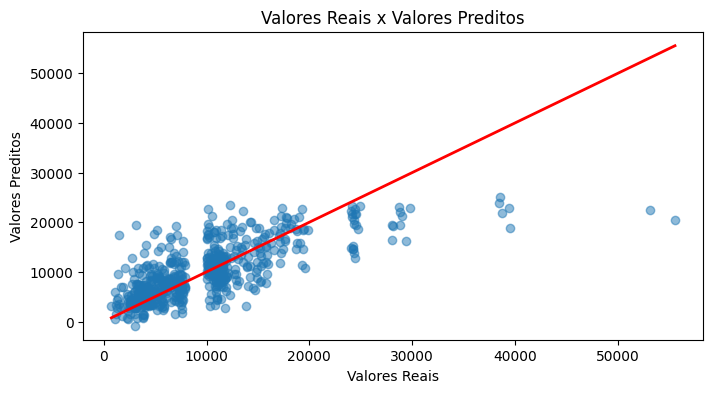

In [ ]:
plt.figure(figsize=(8, 4)) #criando o tamanho do gráfico
plt.scatter(y_test, y_pred, alpha = 0.5) #utilizando gráfico de dispersão, passando os parametros do realizado e real, e alpha é para deixar o pontos com transparência
plt.xlabel('Valores Reais') #nome do eixo x
plt.ylabel('Valores Preditos') #nome do eixo y
plt.title('Valores Reais x Valores Preditos') #título do gráfico
plt.plot([min(y_test), max(y_test)], [min(y_test),max(y_test)], color='red',linewidth=2) #traçando uma reta indicando incio e fim, na cor vermelha e espessura da linha
plt.show() #exibindo o gráfico

#Análise do Gráfico

##A linha representa os valores preditos e as bolinhas em azul os valores reais de salários.
- Abaixo de 10K temos uma grande concentração de bolinhas dos valores reais
- Até valores de 20k temos muitas bolinhas próximas da linha
- Acima desse valor as bolinhas estão distantes e abaixo, sendo assim não casa com a linha de regressão.
- Podemos ajustar o modelo, ou tentar outra métrica de pois esse modelo pode não ser adequado para o nosso problema.
- A maioria dos valores ficaram próximos, então esse será mesmo o modelo.


In [ ]:
nomes_atributos = x_train.columns #salvando os nomes dos atributos em uma variável
nomes_atributos

Index(['IDADE', 'NÃO_BRANCA', 'TEMPO DE EXPERIENCIA', 'INSATISFACAO',
       'NIVEL DE ENSINO', 'NUMERO DE FUNCIONARIOS', 'GENERO_Masculino',
       'GENERO_Prefiro não informar', 'SETOR_Educação',
       'SETOR_Entretenimento ou Esportes', 'SETOR_Filantropia/ONG's',
       'SETOR_Finanças ou Bancos', 'SETOR_Indústria',
       'SETOR_Internet/Ecommerce', 'SETOR_Marketing', 'SETOR_Outra Opção',
       'SETOR_Seguros ou Previdência', 'SETOR_Setor Alimentício',
       'SETOR_Setor Automotivo', 'SETOR_Setor Farmaceutico',
       'SETOR_Setor Imobiliário/ Construção Civil', 'SETOR_Setor Público',
       'SETOR_Setor de Energia', 'SETOR_Tecnologia/Fábrica de Software',
       'SETOR_Telecomunicação', 'SETOR_Varejo', 'SETOR_Área da Saúde',
       'SETOR_Área de Consultoria', 'NOVO_NIVEL_Pessoa Gestora',
       'NOVO_NIVEL_Pleno', 'NOVO_NIVEL_Sênior', 'REGIAO ONDE MORA_Nordeste',
       'REGIAO ONDE MORA_Norte', 'REGIAO ONDE MORA_Sudeste',
       'REGIAO ONDE MORA_Sul'],
      dtype='object')

####Abaixo vamos criar um DataFrame

model.coef_: Esse é o atributo do modelo que contém os coeficientes da regressão linear. Os coeficientes representam a relação entre cada atributo (ou variável independente) e a variável dependente.

- columns=['coeficientes']: Esse parâmetro define o nome da coluna do DataFrame. Nesse caso, a coluna se chama 'coeficientes'.

- index=nomes_atributos: Esse parâmetro define os índices (ou rótulos das linhas) do DataFrame. Nesse caso, os índices são os nomes dos atributos do modelo.

####Quando você combina esses parâmetros, o resultado é um DataFrame com os coeficientes do modelo, onde cada linha representa um atributo e a coluna representa o valor do coeficiente.


In [ ]:
coefs = pd.DataFrame(model.coef_, columns=['coeficientes'], index = nomes_atributos) #criando um dataframe com os coeficientes e salvando em uma variável

In [ ]:
#ordenando a coluna para verificar melhor as influências com sort_values(ordenar)
coefs = coefs.sort_values(by='coeficientes', ascending=False) #escolhendo a colunas

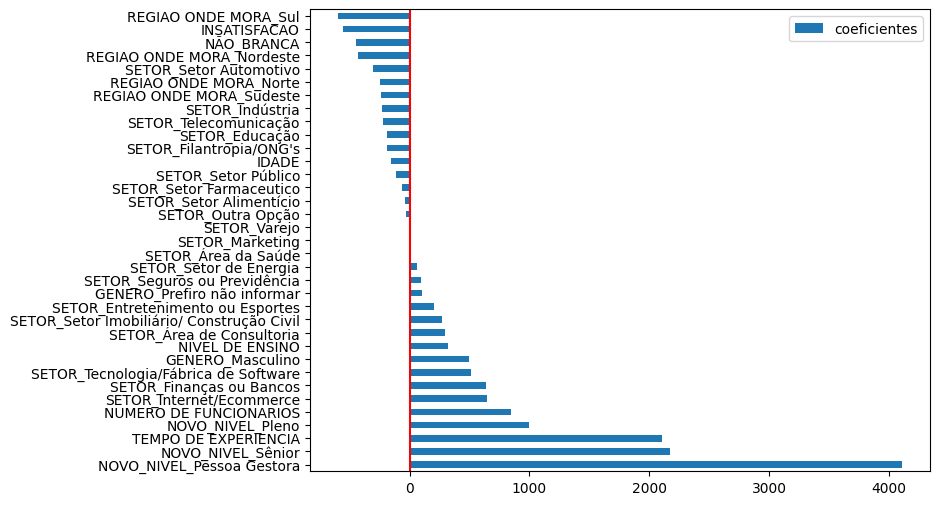

In [ ]:
#plotando gráfico de barras para melhor visualizar
coefs.plot.barh(figsize=(8, 6)) #criando o tamanho do gráfico
plt.axvline(x=0, color= 'red')

#Analisando o Gráfico Acima
##O que mais influencia para a pessoa ter um salário alto foram:
- Nível de Pessoas Gestora
- Nivel Sênior
- Tempo de experiência

##O que mais influencia para diminuir o salário foram:
- Região do Sul aonde moram
- Insatisfação
- Pessoas que moram no nordeste e também teve as Pessoas Não Brancas

#Conclusão

##Para conseguir analisar melhor o modelo, nós pegamos os coeficientes (pesos) de cada atributo, assim a gente conseguiu avaliar quais atributos tiveram mais peso positivo ou negativo para o resultado do modelo. Fizemos um gráfico para deixar mais visual essa questão dos coeficientes e conseguimos observar quais atributos pesaram mais para o negativo e quais pesaram mais para o positivo.